Generating synthetic data...
Running K-Means from Scratch...
Running Scikit-Learn K-Means (for comparison)...

--- Results ---
Silhouette Score (Scratch): 0.8757
Silhouette Score (Sklearn): 0.8757


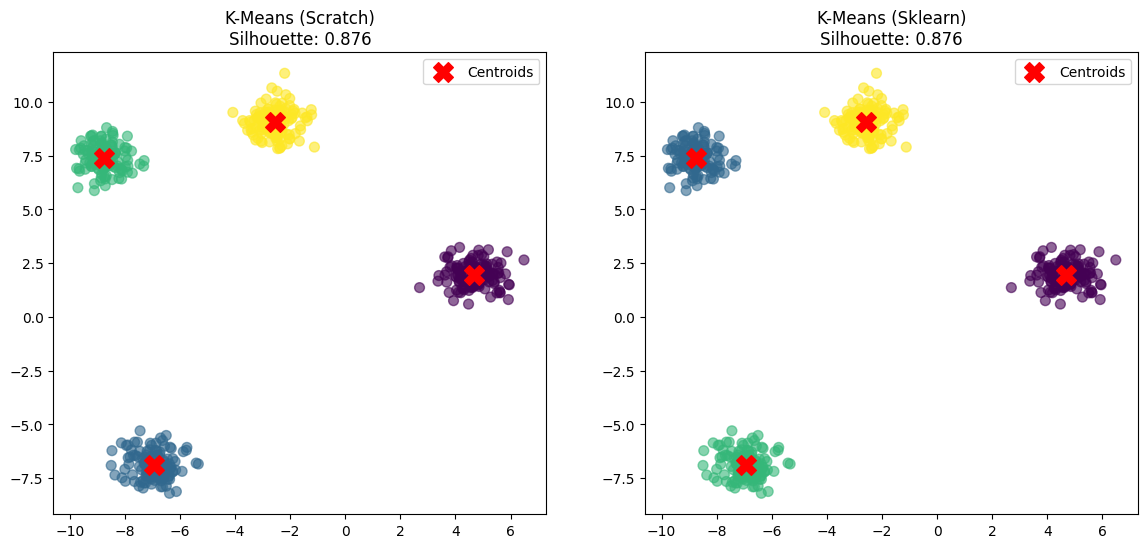

In [1]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans as SklearnKMeans
import time

# --- 1. K-Means Implementation from Scratch ---
class KMeansScratch:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def fit(self, X):
        if self.random_state:
            np.random.seed(self.random_state)

        # Step 1: Initialize centroids randomly from the data points
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[indices]

        for _ in range(self.max_iter):
            # Step 2: Assign clusters (Expectation Step)
            # Calculate distance from each point to each centroid
            distances = self._calculate_distances(X)
            self.labels = np.argmin(distances, axis=1)

            # Step 3: Update centroids (Maximization Step)
            new_centroids = np.array([X[self.labels == k].mean(axis=0) for k in range(self.n_clusters)])

            # Handle empty clusters (rare edge case)
            for k in range(self.n_clusters):
                if np.isnan(new_centroids[k]).any():
                    new_centroids[k] = X[np.random.choice(X.shape[0])]

            # Check for convergence
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break

            self.centroids = new_centroids

    def predict(self, X):
        distances = self._calculate_distances(X)
        return np.argmin(distances, axis=1)

    def _calculate_distances(self, X):
        # Euclidean distance calculation
        # Result shape: (n_samples, n_clusters)
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            # Euclidean distance: sqrt(sum((x - center)^2))
            distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
        return distances

# --- 2. Data Generation ---
print("Generating synthetic data...")
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)

# --- 3. Execution & Comparison ---
print("Running K-Means from Scratch...")
kmeans_scratch = KMeansScratch(n_clusters=4, random_state=42)
kmeans_scratch.fit(X)
labels_scratch = kmeans_scratch.predict(X)

print("Running Scikit-Learn K-Means (for comparison)...")
kmeans_sklearn = SklearnKMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_sklearn.fit(X)
labels_sklearn = kmeans_sklearn.predict(X)

# --- 4. Evaluation ---
sil_scratch = silhouette_score(X, labels_scratch)
sil_sklearn = silhouette_score(X, labels_sklearn)

print(f"\n--- Results ---")
print(f"Silhouette Score (Scratch): {sil_scratch:.4f}")
print(f"Silhouette Score (Sklearn): {sil_sklearn:.4f}")

# --- 5. Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Scratch Results
ax[0].scatter(X[:, 0], X[:, 1], c=labels_scratch, s=50, cmap='viridis', alpha=0.6)
ax[0].scatter(kmeans_scratch.centroids[:, 0], kmeans_scratch.centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
ax[0].set_title(f'K-Means (Scratch)\nSilhouette: {sil_scratch:.3f}')
ax[0].legend()

# Plot Sklearn Results
ax[1].scatter(X[:, 0], X[:, 1], c=labels_sklearn, s=50, cmap='viridis', alpha=0.6)
centers = kmeans_sklearn.cluster_centers_
ax[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
ax[1].set_title(f'K-Means (Sklearn)\nSilhouette: {sil_sklearn:.3f}')
ax[1].legend()

plt.show()